In [ ]:
from src.data_fetch import fetch_stock_list
from src.factors import calc_momentum
from src.backtest import run_backtest
from metrics import calc_ic

# 下载数据
fetch_stock_list(stock_list)

# 合并数据
# 构造因子
# 计算未来收益
# 计算IC
# 回测

In [2]:
import pandas as pd
import glob
import os

# 读取所有股票 CSV
files = glob.glob("../data/*.csv")  # 根据你的notebook目录适配路径

all_data = []

for file in files:
    df = pd.read_csv(file)
    stock = os.path.basename(file).replace(".csv", "")
    df["ts_code"] = stock
    all_data.append(df)

# 合并成一个 DataFrame
all_df = pd.concat(all_data, ignore_index=True)

# 按日期和股票排序
all_df = all_df.sort_values(["trade_date", "ts_code"]).reset_index(drop=True)

# 查看前几行
all_df.head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,000001.SZ,20200102,16.65,16.95,16.55,16.87,16.45,0.42,2.5532,1530231.87,2571196.482
1,000333.SZ,20200102,58.66,59.89,58.41,59.75,58.25,1.50,2.5751,346225.57,2050141.335
2,000858.SZ,20200102,132.00,133.50,129.59,132.08,133.01,-0.93,-0.6992,306674.39,4038536.854
3,002594.SZ,20200102,47.69,48.47,47.51,48.17,47.67,0.50,1.0489,159345.70,765516.493
4,600036.SH,20200102,38.03,39.12,38.02,38.88,37.58,1.30,3.4593,826244.52,3191180.650


In [5]:
# 日期排序

all_df = all_df.sort_values(
    ["ts_code", "trade_date"]
)

# 20日动量

all_df["momentum20"] = (
    all_df.groupby("ts_code")["close"]
          .transform(
              lambda x: x / x.shift(20) - 1
          )
)

all_df.head()
all_df[
    ["ts_code",
     "trade_date",
     "close",
     "momentum20"]
].tail(20)
all_df["future_return_5d"] = (
    all_df.groupby("ts_code")["close"]
          .transform(
              lambda x: x.shift(-5) / x - 1
          )
)
all_df[
    ["ts_code",
     "trade_date",
     "momentum20",
     "future_return_5d"]
].tail()

,ts_code,trade_date,momentum20,future_return_5d
12079,601318.SH,20241225,0.006536,NaN
12089,601318.SH,20241226,0.005266,NaN
12099,601318.SH,20241227,0.000376,NaN
12109,601318.SH,20241230,-0.002037,NaN
12119,601318.SH,20241231,-0.032703,NaN


In [6]:
from scipy.stats import spearmanr
ic_list = []

dates = sorted(
    all_df["trade_date"].unique()
)
for date in dates:

    temp = all_df[
        all_df["trade_date"] == date
    ]

    temp = temp.dropna(
        subset=[
            "momentum20",
            "future_return_5d"
        ]
    )

    if len(temp) < 5:
        continue

    ic, _ = spearmanr(
        temp["momentum20"],
        temp["future_return_5d"]
    )

    ic_list.append(
        {
            "date": date,
            "IC": ic
        }
    )
    ic_df = pd.DataFrame(ic_list)

ic_df.head()
ic_df["IC"].describe()

count    1187.000000
mean        0.001093
std         0.397882
min        -0.975758
25%        -0.296970
50%         0.006061
75%         0.296970
max         0.878788
Name: IC, dtype: float64

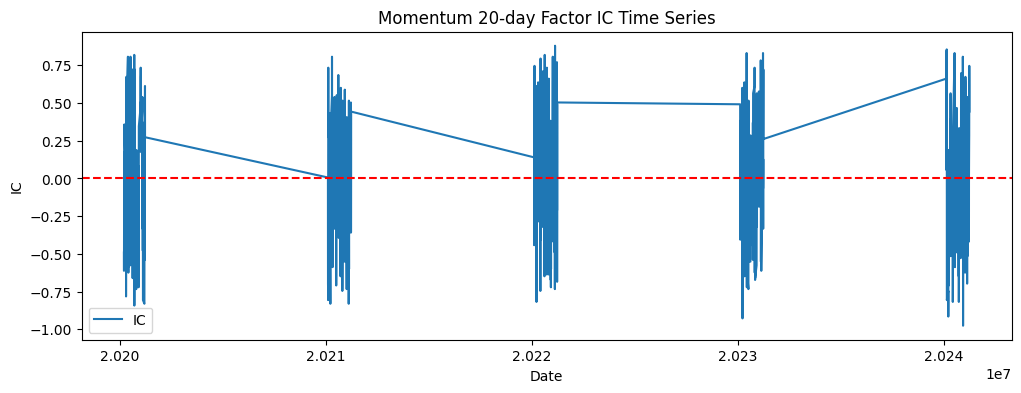

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ic_df['date'], ic_df['IC'], label='IC')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('IC')
plt.title('Momentum 20-day Factor IC Time Series')
plt.legend()
plt.show()

In [8]:
import pandas as pd
import numpy as np
portfolio_returns = []

dates = sorted(all_df["trade_date"].unique())

for date in dates:

    temp = all_df[
        all_df["trade_date"] == date
    ].copy()

    temp = temp.dropna(
        subset=[
            "momentum20",
            "future_return_5d"
        ]
    )

    if len(temp) < 5:
        continue

    # 因子从大到小排序
    temp = temp.sort_values(
        "momentum20",
        ascending=False
    )

    # Top30%
    n = max(1, int(len(temp) * 0.3))

    selected = temp.head(n)

    # 等权平均收益
    ret = selected["future_return_5d"].mean()

    portfolio_returns.append(
        {
            "date": date,
            "return": ret
        }
    )
    portfolio_df = pd.DataFrame(
    portfolio_returns
)

portfolio_df.head()
portfolio_df["cum_return"] = (
    1 + portfolio_df["return"]
).cumprod()
portfolio_df.tail()

,date,return,cum_return
1182,20241218,0.024666,9.562620
1183,20241219,0.031922,9.867878
1184,20241220,0.033909,10.202486
1185,20241223,0.027140,10.479384
1186,20241224,-0.000662,10.472451


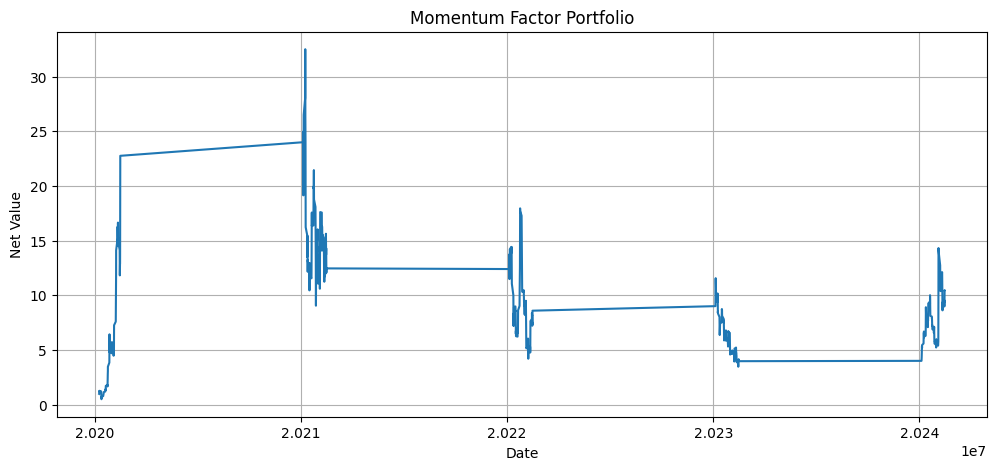

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    portfolio_df["date"],
    portfolio_df["cum_return"]
)

plt.title(
    "Momentum Factor Portfolio"
)

plt.xlabel("Date")
plt.ylabel("Net Value")

plt.grid()

plt.show()

In [10]:
total_return = (
    portfolio_df["cum_return"].iloc[-1] - 1
)

years = len(portfolio_df) / 244

annual_return = (
    portfolio_df["cum_return"].iloc[-1]
) ** (1 / years) - 1

print(
    "Annual Return:",
    round(annual_return * 100, 2),
    "%"
)

Annual Return: 62.06 %


In [11]:
rf = 0
sharpe = (
    portfolio_df["return"].mean()
    /
    portfolio_df["return"].std()
) * np.sqrt(244)

print(
    "Sharpe Ratio:",
    round(sharpe, 3)
)

Sharpe Ratio: 1.101


In [12]:
rolling_max = (
    portfolio_df["cum_return"]
    .cummax()
)

drawdown = (
    portfolio_df["cum_return"]
    /
    rolling_max
    - 1
)

max_drawdown = drawdown.min()

print(
    "Max Drawdown:",
    round(max_drawdown * 100, 2),
    "%"
)

Max Drawdown: -89.3 %


In [13]:
ic_mean = ic_df["IC"].mean()

ic_std = ic_df["IC"].std()

icir = (
    ic_mean
    /
    ic_std
)

print(
    "IC Mean:",
    round(ic_mean,4)
)

print(
    "ICIR:",
    round(icir,4)
)

IC Mean: 0.0011
ICIR: 0.0027
